In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from collections import Counter
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import warnings
warnings.filterwarnings('ignore')

In [6]:
# ── CONFIG ──────────────────────────────────────────────────────────────
DATA_ROOT   = "/kaggle/input/datasets/avanthikasuraj/ucf101-20/ucf101 dataset"
TRAIN_DIR   = os.path.join(DATA_ROOT, "train")
VAL_DIR     = os.path.join(DATA_ROOT, "val")
TEST_DIR    = os.path.join(DATA_ROOT, "test")

IMG_SIZE    = 64        # resize each frame to 64x64
FRAME_IDX   = 0.5      # extract middle frame (0.5 = 50% through video)
BATCH_SIZE  = 32
EPOCHS      = 30
LR          = 1e-3
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED        = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Device: {DEVICE}")
print(f"Train : {TRAIN_DIR}")

Device: cuda
Train : /kaggle/input/datasets/avanthikasuraj/ucf101-20/ucf101 dataset/train


Extract Frames

In [7]:
def extract_frame(video_path, position=0.5):
    """Extract one frame from a video at `position` (0.0=start, 1.0=end)."""
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    target = max(0, min(int(total * position), total - 1))
    cap.set(cv2.CAP_PROP_POS_FRAMES, target)
    ret, frame = cap.read()
    cap.release()
    if not ret:
        return None
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
    return frame  # (H, W, 3) uint8

In [8]:
def load_split(split_dir):
    """Load all videos from a split directory. Returns (frames, labels, class_names)."""
    class_names = sorted(os.listdir(split_dir))
    class_to_idx = {c: i for i, c in enumerate(class_names)}
    
    frames, labels = [], []
    skipped = 0
    
    for cls in class_names:
        cls_path = os.path.join(split_dir, cls)
        if not os.path.isdir(cls_path):
            continue
        for vid in os.listdir(cls_path):
            vid_path = os.path.join(cls_path, vid)
            frame = extract_frame(vid_path, FRAME_IDX)
            if frame is None:
                skipped += 1
                continue
            frames.append(frame)
            labels.append(class_to_idx[cls])
    
    print(f"  Loaded {len(frames)} samples | Skipped {skipped} | Classes: {len(class_names)}")
    return np.array(frames), np.array(labels), class_names


print("Loading train...")
X_train, y_train, CLASS_NAMES = load_split(TRAIN_DIR)
print("Loading val...")
X_val,   y_val,   _           = load_split(VAL_DIR)
print("Loading test...")
X_test,  y_test,  _           = load_split(TEST_DIR)

NUM_CLASSES = len(CLASS_NAMES)
print(f"\nClasses ({NUM_CLASSES}): {CLASS_NAMES}")

Loading train...
  Loaded 2587 samples | Skipped 0 | Classes: 25
Loading val...
  Loaded 411 samples | Skipped 0 | Classes: 24
Loading test...
  Loaded 443 samples | Skipped 0 | Classes: 25

Classes (25): ['ApplyEyeMakeup', 'ApplyLipstick', 'BabyCrawling', 'Basketball', 'BenchPress', 'Biking', 'BlowDryHair', 'Bowling', 'CliffDiving', 'CricketShot', 'SumoWrestling', 'Surfing', 'Swing', 'TableTennisShot', 'TaiChi', 'TennisSwing', 'ThrowDiscus', 'TrampolineJumping', 'Typing', 'UnevenBars', 'VolleyballSpiking', 'WalkingWithDog', 'WallPushups', 'WritingOnBoard', 'YoYo']


Data Preprocessing

In [9]:
# ── Normalize to [0, 1] ──────────────────────────────────────────────────
X_train_norm = X_train.astype(np.float32) / 255.0
X_val_norm   = X_val.astype(np.float32)   / 255.0
X_test_norm  = X_test.astype(np.float32)  / 255.0

# ── Per-channel mean/std on train, applied to all ────────────────────────
mean = X_train_norm.mean(axis=(0,1,2))   # (3,)
std  = X_train_norm.std(axis=(0,1,2))    # (3,)
std  = np.where(std == 0, 1e-6, std)

X_train_norm = (X_train_norm - mean) / std
X_val_norm   = (X_val_norm   - mean) / std
X_test_norm  = (X_test_norm  - mean) / std

print(f"Train mean (post-norm): {X_train_norm.mean():.4f}  std: {X_train_norm.std():.4f}")
print(f"Normalization mean per channel : {mean}")
print(f"Normalization std  per channel : {std}")

Train mean (post-norm): 0.0011  std: 1.0083
Normalization mean per channel : [0.395191  0.3769768 0.3424777]
Normalization std  per channel : [0.28639495 0.2754989  0.27455637]


Augmentation

In [10]:
# ── Augmentation transforms for CNN DataLoader ───────────────────────────
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.tolist(), std=std.tolist()),
])

eval_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.tolist(), std=std.tolist()),
])

print("\nAugmentation pipeline (CNN train): HorizontalFlip | Rotation±10° | ColorJitter")
print("No augmentation leakage to val/test.")


Augmentation pipeline (CNN train): HorizontalFlip | Rotation±10° | ColorJitter
No augmentation leakage to val/test.


Dataset Loader

In [11]:
class ActionDataset(Dataset):
    def __init__(self, frames, labels, transform=None):
        # frames: (N, H, W, 3) uint8
        self.frames    = frames
        self.labels    = torch.tensor(labels, dtype=torch.long)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.frames[idx]          # (H, W, 3) uint8
        if self.transform:
            img = self.transform(img)   # → (3, H, W) float tensor
        else:
            img = torch.tensor(img.transpose(2,0,1), dtype=torch.float32) / 255.0
        return img, self.labels[idx]


# CNN datasets (with augmentation for train)
train_ds_cnn = ActionDataset(X_train, y_train, transform=train_transform)
val_ds_cnn   = ActionDataset(X_val,   y_val,   transform=eval_transform)
test_ds_cnn  = ActionDataset(X_test,  y_test,  transform=eval_transform)

train_loader = DataLoader(train_ds_cnn, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds_cnn,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds_cnn,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# MLP uses pre-normalised flattened numpy arrays
FLAT = IMG_SIZE * IMG_SIZE * 3
X_train_flat = X_train_norm.reshape(-1, FLAT)
X_val_flat   = X_val_norm.reshape(-1, FLAT)
X_test_flat  = X_test_norm.reshape(-1, FLAT)

X_train_t = torch.tensor(X_train_flat, dtype=torch.float32)
y_train_t = torch.tensor(y_train,      dtype=torch.long)
X_val_t   = torch.tensor(X_val_flat,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,        dtype=torch.long)
X_test_t  = torch.tensor(X_test_flat,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,       dtype=torch.long)

from torch.utils.data import TensorDataset
mlp_train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
mlp_val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=BATCH_SIZE, shuffle=False)
mlp_test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=BATCH_SIZE, shuffle=False)

print(f"CNN DataLoaders ready. Train batches: {len(train_loader)}")
print(f"MLP flattened dim: {FLAT}")

CNN DataLoaders ready. Train batches: 81
MLP flattened dim: 12288


MLP

In [26]:
class MLP(nn.Module):
    
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.net(x)


mlp_model = MLP(FLAT, NUM_CLASSES).to(DEVICE)
mlp_params = sum(p.numel() for p in mlp_model.parameters() if p.requires_grad)
print(f"\nMLP trainable parameters: {mlp_params:,}")


MLP trainable parameters: 13,250,073


CNN

In [27]:
class CNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        def conv_block(in_ch, out_ch, dropout=0.25):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2),
                nn.Dropout2d(dropout),
            )

        self.features = nn.Sequential(
            conv_block(3,   32,  0.25),   # 64 → 32
            conv_block(32,  64,  0.25),   # 32 → 16
            conv_block(64,  128, 0.30),   # 16 → 8
            conv_block(128, 256, 0.30),   # 8  → 4
        )

        self.gap = nn.AdaptiveAvgPool2d(1)  # Global Average Pooling

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        return self.classifier(x)


cnn_model = CNN(NUM_CLASSES).to(DEVICE)
cnn_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"\nCNN trainable parameters: {cnn_params:,}")
print(f"MLP parameters          : {mlp_params:,}")
print(f"Parameter ratio CNN/MLP : {cnn_params/mlp_params:.2f}x")


CNN trainable parameters: 1,319,609
MLP parameters          : 13,250,073
Parameter ratio CNN/MLP : 0.10x


Training Loop

In [28]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out  = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * y.size(0)
        correct    += (out.argmax(1) == y).sum().item()
        total      += y.size(0)
    return total_loss / total, correct / total

In [29]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            out  = model(X)
            loss = criterion(out, y)
            total_loss += loss.item() * y.size(0)
            preds = out.argmax(1)
            correct += (preds == y).sum().item()
            total   += y.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels

In [30]:
def run_training(model, train_loader, val_loader, epochs, lr, label="Model"):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
    best_val_acc = 0
    best_state   = None

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc             = train_one_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc, _, _       = evaluate(model, val_loader, criterion)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 5 == 0 or epoch == 1:
            print(f"[{label}] Epoch {epoch:3d}/{epochs} | "
                  f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
                  f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}")

    model.load_state_dict(best_state)
    print(f"\n[{label}] Best Val Acc: {best_val_acc:.4f}")
    return history

In [31]:
print("=" * 50)
print("TRAINING MLP")
print("=" * 50)
mlp_history = run_training(
    mlp_model, mlp_train_loader, mlp_val_loader,
    epochs=EPOCHS, lr=LR, label="MLP"
)

TRAINING MLP
[MLP] Epoch   1/30 | Train Loss: 2.9715 Acc: 0.1299 | Val Loss: 3.1985 Acc: 0.1192
[MLP] Epoch   5/30 | Train Loss: 1.9213 Acc: 0.4283 | Val Loss: 3.3723 Acc: 0.1582
[MLP] Epoch  10/30 | Train Loss: 1.3321 Acc: 0.5945 | Val Loss: 3.9060 Acc: 0.2287
[MLP] Epoch  15/30 | Train Loss: 0.7932 Acc: 0.7611 | Val Loss: 4.5312 Acc: 0.2384
[MLP] Epoch  20/30 | Train Loss: 0.6460 Acc: 0.8036 | Val Loss: 5.1734 Acc: 0.2263
[MLP] Epoch  25/30 | Train Loss: 0.3733 Acc: 0.8937 | Val Loss: 5.3391 Acc: 0.2555
[MLP] Epoch  30/30 | Train Loss: 0.2993 Acc: 0.9123 | Val Loss: 5.5561 Acc: 0.2603

[MLP] Best Val Acc: 0.2725


In [32]:
print("=" * 50)
print("TRAINING CNN")
print("=" * 50)
cnn_history = run_training(
    cnn_model, train_loader, val_loader,
    epochs=EPOCHS, lr=LR, label="CNN"
)

TRAINING CNN
[CNN] Epoch   1/30 | Train Loss: 3.1732 Acc: 0.0816 | Val Loss: 3.2729 Acc: 0.0535
[CNN] Epoch   5/30 | Train Loss: 2.4624 Acc: 0.2416 | Val Loss: 3.2733 Acc: 0.1582
[CNN] Epoch  10/30 | Train Loss: 2.1250 Acc: 0.3332 | Val Loss: 3.3937 Acc: 0.2263
[CNN] Epoch  15/30 | Train Loss: 1.7716 Acc: 0.4445 | Val Loss: 3.8083 Acc: 0.1922
[CNN] Epoch  20/30 | Train Loss: 1.6289 Acc: 0.4836 | Val Loss: 3.9674 Acc: 0.2603
[CNN] Epoch  25/30 | Train Loss: 1.4442 Acc: 0.5358 | Val Loss: 4.0228 Acc: 0.2457
[CNN] Epoch  30/30 | Train Loss: 1.3568 Acc: 0.5589 | Val Loss: 4.1449 Acc: 0.2676

[CNN] Best Val Acc: 0.2676


Hyperparameter Tning Experiments

In [33]:
# We retrain with 2 alternate LR values to show tuning experiments
print("Hyperparameter Tuning: Testing different learning rates on CNN")

lr_results = {}
for test_lr in [1e-2, 1e-3, 5e-4]:
    temp_model = CNN(NUM_CLASSES).to(DEVICE)
    criterion  = nn.CrossEntropyLoss()
    optimizer  = optim.Adam(temp_model.parameters(), lr=test_lr, weight_decay=1e-4)
    
    # Train for 10 quick epochs only
    for _ in range(10):
        train_one_epoch(temp_model, train_loader, criterion, optimizer)
    
    _, val_acc, _, _ = evaluate(temp_model, val_loader, criterion)
    lr_results[test_lr] = round(val_acc, 4)
    print(f"  LR={test_lr:.4f}  →  Val Acc: {val_acc:.4f}")

best_lr = max(lr_results, key=lr_results.get)
print(f"\nBest LR from sweep: {best_lr} → Val Acc: {lr_results[best_lr]}")

Hyperparameter Tuning: Testing different learning rates on CNN
  LR=0.0100  →  Val Acc: 0.1557
  LR=0.0010  →  Val Acc: 0.1971
  LR=0.0005  →  Val Acc: 0.2092

Best LR from sweep: 0.0005 → Val Acc: 0.2092


Learning Curves

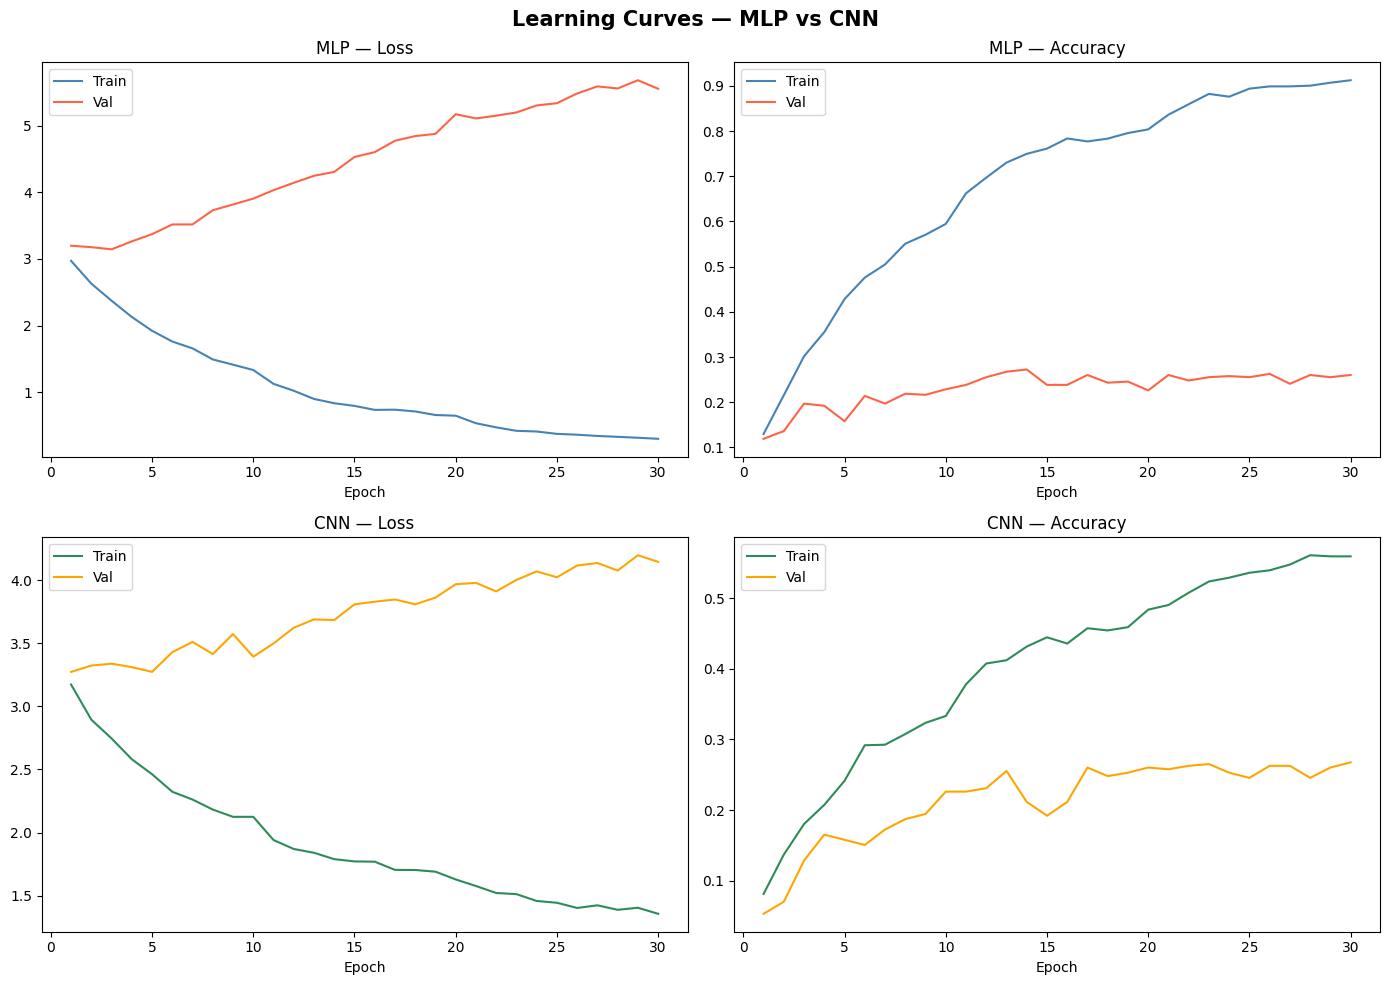

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Learning Curves — MLP vs CNN", fontsize=15, fontweight='bold')

epochs_range = range(1, EPOCHS + 1)

# MLP Loss
axes[0,0].plot(epochs_range, mlp_history["train_loss"], label="Train", color="steelblue")
axes[0,0].plot(epochs_range, mlp_history["val_loss"],   label="Val",   color="tomato")
axes[0,0].set_title("MLP — Loss");  axes[0,0].set_xlabel("Epoch"); axes[0,0].legend()

# MLP Accuracy
axes[0,1].plot(epochs_range, mlp_history["train_acc"], label="Train", color="steelblue")
axes[0,1].plot(epochs_range, mlp_history["val_acc"],   label="Val",   color="tomato")
axes[0,1].set_title("MLP — Accuracy"); axes[0,1].set_xlabel("Epoch"); axes[0,1].legend()

# CNN Loss
axes[1,0].plot(epochs_range, cnn_history["train_loss"], label="Train", color="seagreen")
axes[1,0].plot(epochs_range, cnn_history["val_loss"],   label="Val",   color="orange")
axes[1,0].set_title("CNN — Loss");  axes[1,0].set_xlabel("Epoch"); axes[1,0].legend()

# CNN Accuracy
axes[1,1].plot(epochs_range, cnn_history["train_acc"], label="Train", color="seagreen")
axes[1,1].plot(epochs_range, cnn_history["val_acc"],   label="Val",   color="orange")
axes[1,1].set_title("CNN — Accuracy"); axes[1,1].set_xlabel("Epoch"); axes[1,1].legend()

plt.tight_layout()
plt.savefig("learning_curves.png", dpi=150)
plt.show()

Confusion matrix

MLP Test Accuracy : 0.6366
CNN Test Accuracy : 0.6659


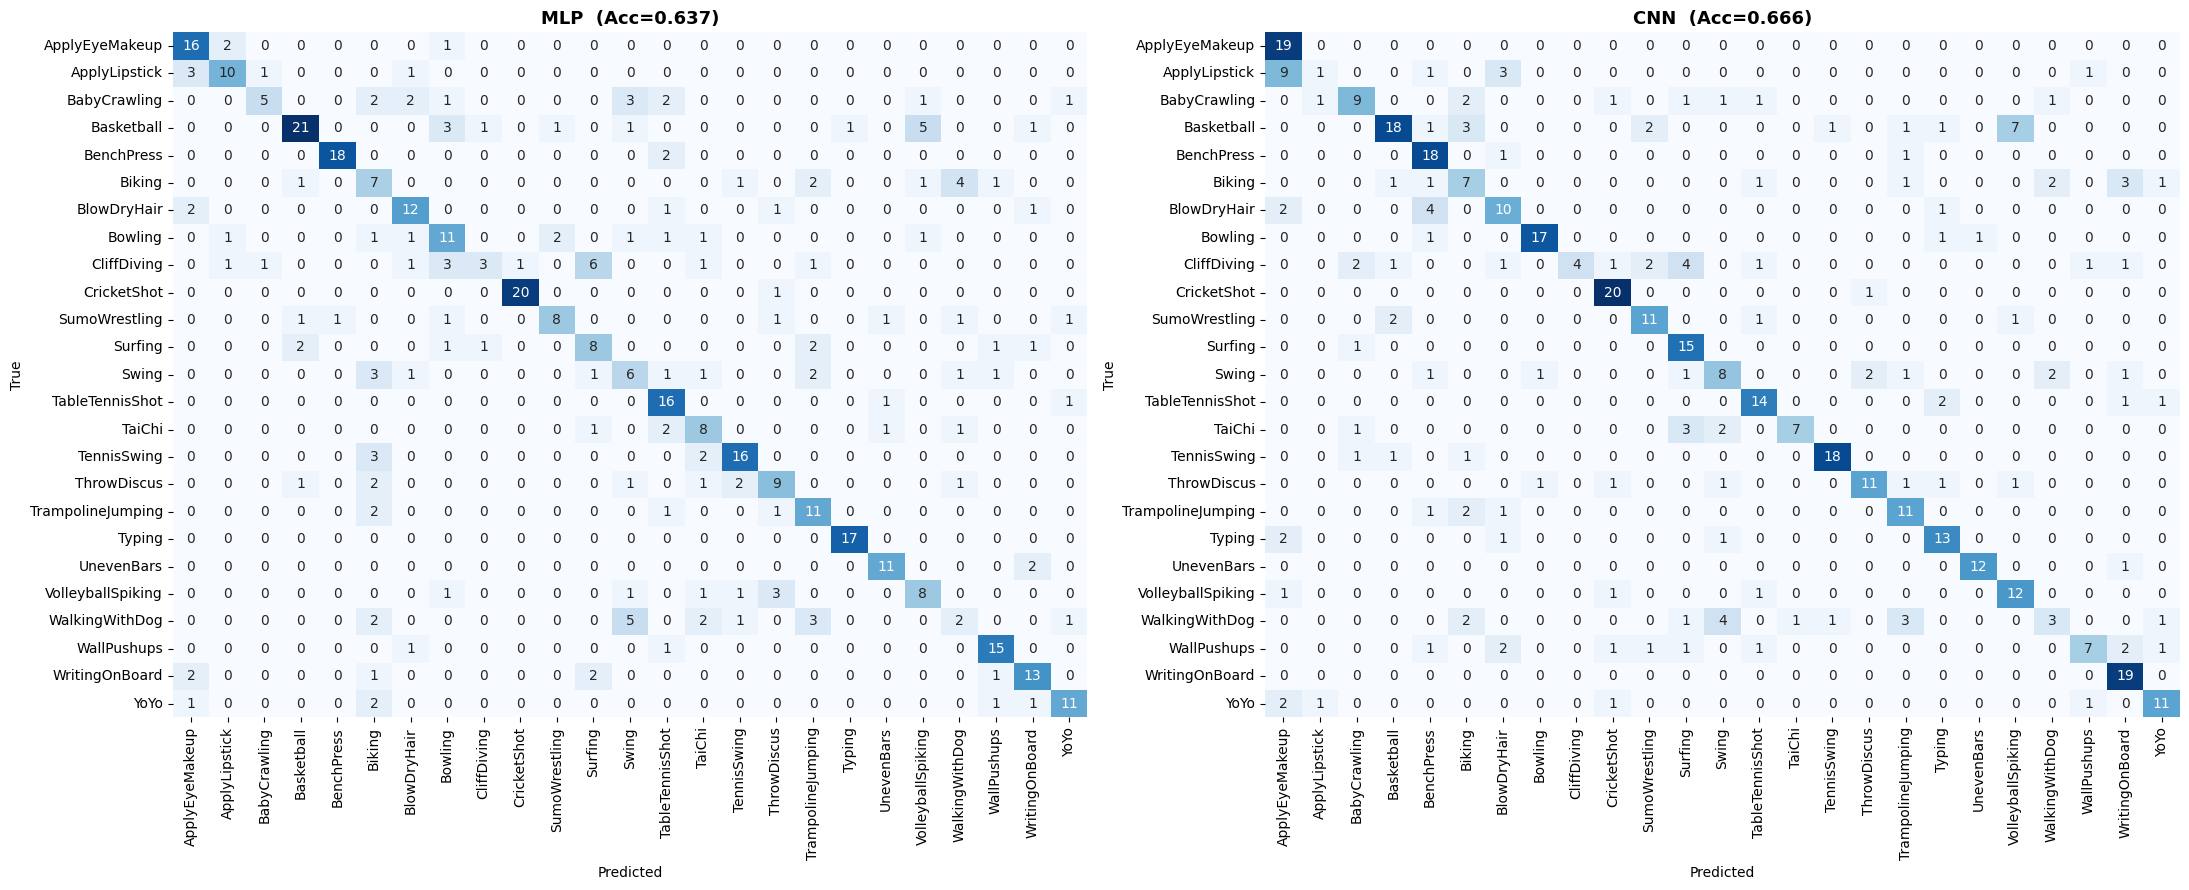

In [35]:
criterion_eval = nn.CrossEntropyLoss()

_, mlp_test_acc, mlp_preds, mlp_true = evaluate(mlp_model, mlp_test_loader, criterion_eval)
_, cnn_test_acc, cnn_preds, cnn_true = evaluate(cnn_model, test_loader,     criterion_eval)

print(f"MLP Test Accuracy : {mlp_test_acc:.4f}")
print(f"CNN Test Accuracy : {cnn_test_acc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

for ax, preds, true, title in [
    (axes[0], mlp_preds, mlp_true, f"MLP  (Acc={mlp_test_acc:.3f})"),
    (axes[1], cnn_preds, cnn_true, f"CNN  (Acc={cnn_test_acc:.3f})"),
]:
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, cbar=False)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.tick_params(axis='x', rotation=90)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()

Comparitive Analysis

In [36]:
print("=" * 65)
print("COMPARATIVE ANALYSIS: MLP vs CNN")
print("=" * 65)

mlp_report = classification_report(mlp_true, mlp_preds, target_names=CLASS_NAMES, output_dict=True)
cnn_report = classification_report(cnn_true, cnn_preds, target_names=CLASS_NAMES, output_dict=True)

print(f"\n{'Metric':<30} {'MLP':>10} {'CNN':>10}")
print("-" * 52)
print(f"{'Test Accuracy':<30} {mlp_test_acc:>10.4f} {cnn_test_acc:>10.4f}")
print(f"{'Macro F1-Score':<30} {mlp_report['macro avg']['f1-score']:>10.4f} {cnn_report['macro avg']['f1-score']:>10.4f}")
print(f"{'Macro Precision':<30} {mlp_report['macro avg']['precision']:>10.4f} {cnn_report['macro avg']['precision']:>10.4f}")
print(f"{'Macro Recall':<30} {mlp_report['macro avg']['recall']:>10.4f} {cnn_report['macro avg']['recall']:>10.4f}")
print(f"{'Trainable Parameters':<30} {mlp_params:>10,} {cnn_params:>10,}")
print(f"{'Best Val Acc':<30} {max(mlp_history['val_acc']):>10.4f} {max(cnn_history['val_acc']):>10.4f}")

gap_mlp = max(mlp_history['train_acc']) - mlp_test_acc
gap_cnn = max(cnn_history['train_acc']) - cnn_test_acc
print(f"{'Train-Test Gap (overfit)':<30} {gap_mlp:>10.4f} {gap_cnn:>10.4f}")

COMPARATIVE ANALYSIS: MLP vs CNN

Metric                                MLP        CNN
----------------------------------------------------
Test Accuracy                      0.6366     0.6659
Macro F1-Score                     0.6185     0.6379
Macro Precision                    0.6331     0.6706
Macro Recall                       0.6312     0.6608
Trainable Parameters           13,250,073  1,319,609
Best Val Acc                       0.2725     0.2676
Train-Test Gap (overfit)           0.2757    -0.1054


Bar PLot

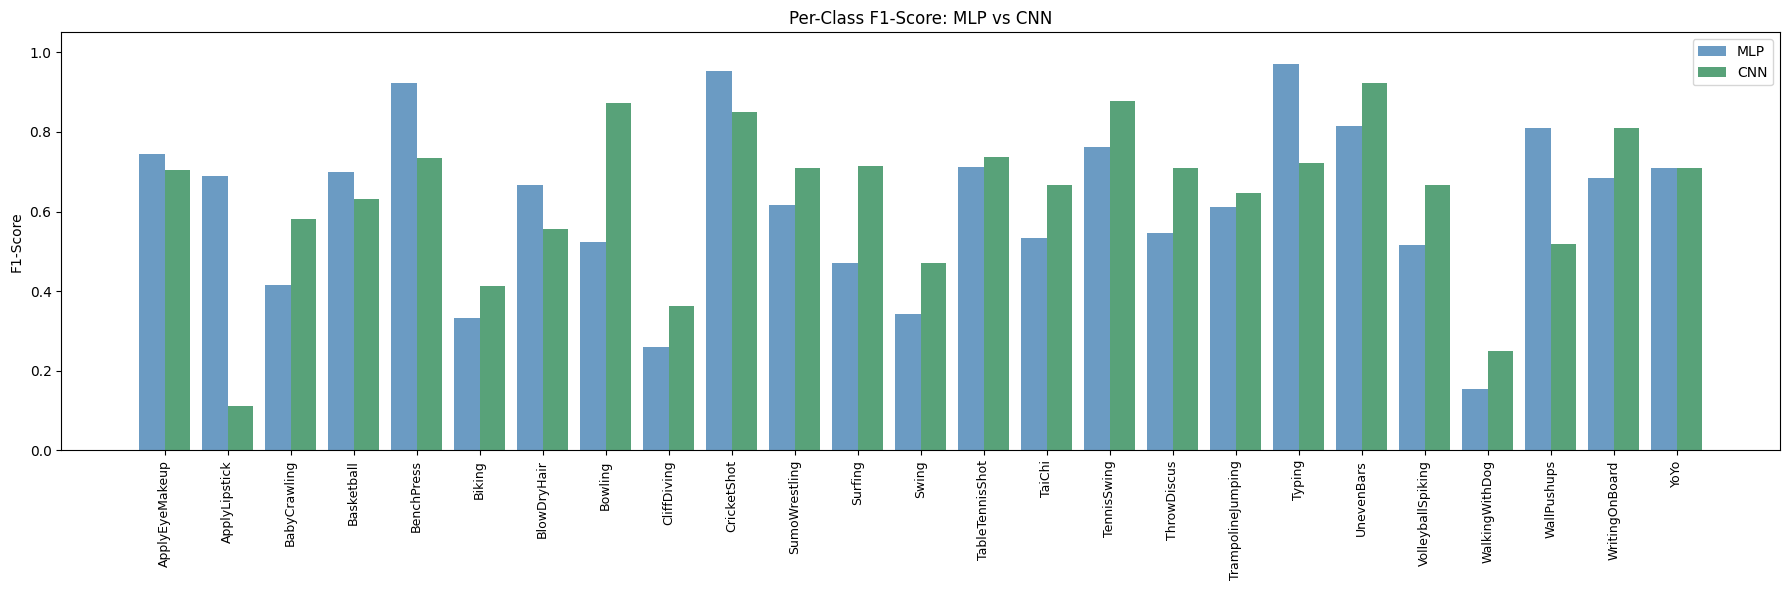

In [37]:
classes = list(range(NUM_CLASSES))
mlp_f1 = [mlp_report[c]['f1-score'] for c in CLASS_NAMES]
cnn_f1 = [cnn_report[c]['f1-score'] for c in CLASS_NAMES]

x = np.arange(NUM_CLASSES)
width = 0.4

fig, ax = plt.subplots(figsize=(18, 6))
ax.bar(x - width/2, mlp_f1, width, label='MLP', color='steelblue', alpha=0.8)
ax.bar(x + width/2, cnn_f1, width, label='CNN', color='seagreen',  alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=9)
ax.set_ylabel("F1-Score")
ax.set_title("Per-Class F1-Score: MLP vs CNN")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig("per_class_f1.png", dpi=150)
plt.show()

In [38]:
print("=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"""

MLP Test Acc   : {mlp_test_acc:.4f}
CNN Test Acc   : {cnn_test_acc:.4f}

""")

FINAL SUMMARY


MLP Test Acc   : 0.6366
CNN Test Acc   : 0.6659


